# Customer Churn Prediction

## Overview
This project predicts customer churn based on e-commerce customer behavior data.  
Churn is defined as customers who have not made a purchase for more than 30 days.

## Methods
- Data preprocessing using pandas  
- Train-test split for model evaluation  
- Models: Random Forest, Logistic Regression  
- Evaluation: Accuracy, Confusion Matrix, ROC Curve  

## Tools
Python, pandas, scikit-learn, matplotlib, seaborn

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [7]:
df = pd.read_csv("E-commerce Customer Behavior - Sheet1.csv")

df = df.copy()

numeric_cols = [
    'Age',
    'Total Spend',
    'Items Purchased',
    'Average Rating',
    'Days Since Last Purchase'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.dropna(subset=numeric_cols)

In [8]:
#Create churn target
#Churn is defined as customers who have not purchased for more than 30 days.
df['Churn'] = (df['Days Since Last Purchase'] > 30).astype(int)

print("Churn distribution:")
print(df['Churn'].value_counts())

Churn distribution:
Churn
0    226
1    124
Name: count, dtype: int64


In [9]:
features = [
    'Age',
    'Total Spend',
    'Items Purchased',
    'Average Rating'
]

X = df[features]
y = df['Churn']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Random Forest Results
Accuracy: 0.9714
ROC-AUC: 0.9987

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        45
           1       1.00      0.92      0.96        25

    accuracy                           0.97        70
   macro avg       0.98      0.96      0.97        70
weighted avg       0.97      0.97      0.97        70



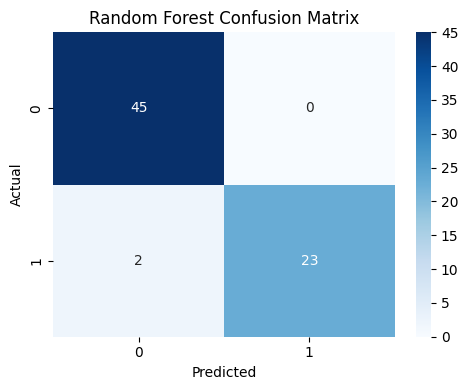

In [11]:
#Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]


print("\nRandom Forest Results")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_prob), 4))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [12]:
#Logistic Regression comparison
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

print("\nLogistic Regression Results")
print("Accuracy:", round(accuracy_score(y_test, log_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, log_prob), 4))
print("\nClassification Report:")
print(classification_report(y_test, log_pred))


Logistic Regression Results
Accuracy: 0.8429
ROC-AUC: 0.8591

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88        45
           1       0.82      0.72      0.77        25

    accuracy                           0.84        70
   macro avg       0.84      0.82      0.82        70
weighted avg       0.84      0.84      0.84        70



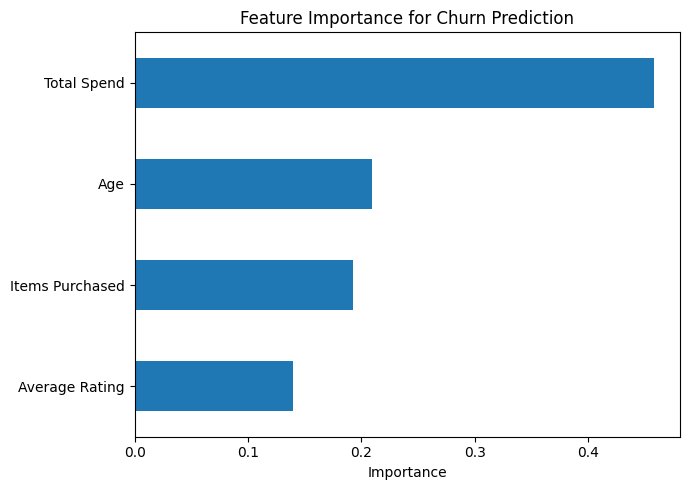

In [13]:
#Feature importance
importance = pd.Series(
    rf_model.feature_importances_,
    index=features
).sort_values()

plt.figure(figsize=(7, 5))
importance.plot(kind='barh')
plt.title("Feature Importance for Churn Prediction")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

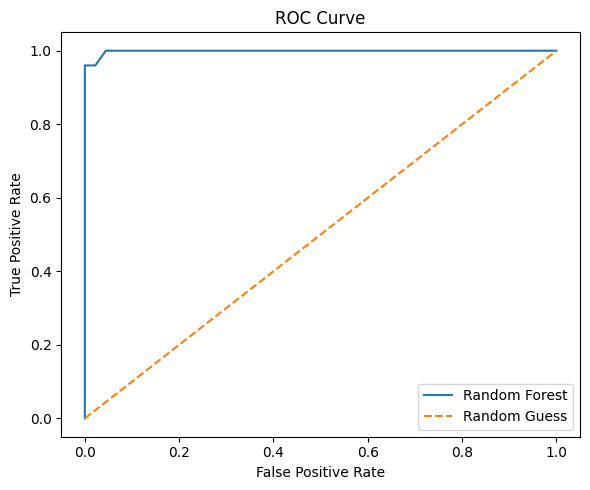

In [14]:
#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle='--', label="Random Guess")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## Business Insights

- Customers who have not purchased for over 30 days are considered at risk of churn.  
- To ensure model validity, *Days Since Last Purchase* was removed to prevent data leakage.  
- The model effectively identifies high-risk customers based on behavioral patterns.  
- These customers can be targeted with retention strategies such as promotions, discounts, and personalised marketing campaigns.